1. OBJETIVO DO MODELO
Classificar se um veículo possui preço alto ou não, com base em suas características.

2. OBTENDO OS DADOS
Arquivo carregado com sucesso (UTF-16)

3. EXPLORAÇÃO DOS DADOS
Primeiras linhas:
       km   ano  combustivel  marca  cambio  preco_alto
0  152315  2022            2      2       1           1
1  151439  2024            0      1       1           1
2  145623  2011            2      2       1           0
3  156695  2014            0      1       1           0
4   20359  2017            2      0       0           0

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   km           20 non-null     int64
 1   ano          20 non-null     int64
 2   combustivel  20 non-null     int64
 3   marca        20 non-null     int64
 4   cambio       20 non-null     int64
 5   preco_alto   20 non-null     int64
dtypes: in

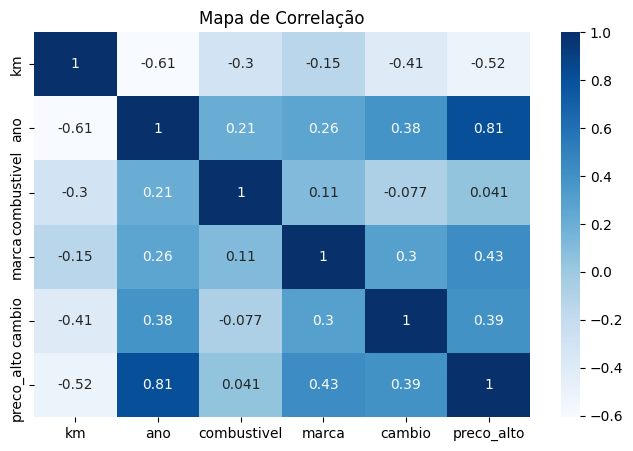

7. DIVISÃO ENTRE TREINO E TESTE
Tamanho treino: (15, 5)
Tamanho teste: (5, 5)

8. DEFINIÇÃO E TREINAMENTO DO MODELO
9. VALIDAÇÃO DO MODELO
Acurácia alcançada: 80.00%

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5




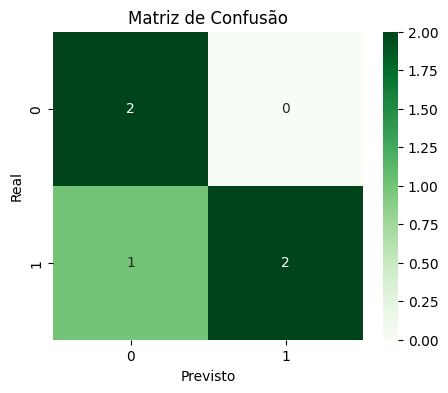

10. SALVANDO A SOLUÇÃO
Arquivo 'modelo_concessionaria_v1.pkl' gerado com sucesso!


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

print("1. OBJETIVO DO MODELO")
print("Classificar se um veículo possui preço alto ou não, com base em suas características.")
print()

print("2. OBTENDO OS DADOS")
try:
    df = pd.read_csv('dados_concessionaria.csv', encoding='utf-16')
    print("Arquivo carregado com sucesso (UTF-16)")
except:
    df = pd.read_csv('dados_concessionaria.csv', encoding='latin-1')
    print("Arquivo carregado com sucesso (Latin-1)")

print()

print("3. EXPLORAÇÃO DOS DADOS")
print("Primeiras linhas:")
print(df.head())
print()
print("Informações gerais:")
print(df.info())
print()
print("Valores ausentes:")
print(df.isnull().sum())
print()
print("Distribuição da variável alvo:")
print(df['preco_alto'].value_counts())
print()

print("4. TRATAMENTO DOS DADOS")
df = df.drop_duplicates()

if df.isnull().sum().sum() > 0:
    for coluna in df.columns:
        if df[coluna].dtype == 'object':
            df[coluna] = df[coluna].fillna(df[coluna].mode()[0])
        else:
            df[coluna] = df[coluna].fillna(df[coluna].median())

print("Valores ausentes após tratamento:")
print(df.isnull().sum())
print()

print("5. SEPARAÇÃO EM ARRAYS")
X = df.drop('preco_alto', axis=1)
y = df['preco_alto']

print("6. PRÉ-PROCESSAMENTO")
label_encoders = {}

for coluna in X.columns:
    if X[coluna].dtype == 'object':
        le = LabelEncoder()
        X[coluna] = le.fit_transform(X[coluna])
        label_encoders[coluna] = le

if y.dtype == 'object':
    le_y = LabelEncoder()
    y = le_y.fit_transform(y)
    label_encoders['preco_alto'] = le_y

print()

print("Mapa de correlação:")
plt.figure(figsize=(8, 5))
sns.heatmap(pd.concat([X, pd.Series(y, name='preco_alto')], axis=1).corr(), annot=True, cmap='Blues')
plt.title("Mapa de Correlação")
plt.show()

print("7. DIVISÃO ENTRE TREINO E TESTE")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Tamanho treino:", X_train.shape)
print("Tamanho teste:", X_test.shape)
print()

print("8. DEFINIÇÃO E TREINAMENTO DO MODELO")
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

print("9. VALIDAÇÃO DO MODELO")
previsoes = modelo.predict(X_test)
acuracia = accuracy_score(y_test, previsoes)

print(f"Acurácia alcançada: {acuracia * 100:.2f}%")
print()
print("Relatório de classificação:")
print(classification_report(y_test, previsoes))
print()

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, previsoes), annot=True, fmt='d', cmap='Greens')
plt.title("Matriz de Confusão")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

print("10. SALVANDO A SOLUÇÃO")
joblib.dump(modelo, 'modelo_concessionaria_v1.pkl')
print("Arquivo 'modelo_concessionaria_v1.pkl' gerado com sucesso!")